In [1]:
# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '../')

import nn_fncs

mat_data = nn_fncs.read_mat_workspace('../Data/motor_model_1e-4.mat') # data sampled at 1e-4s, only 100 trajectories
# mat_data = nn_fncs.read_mat_workspace('motor_model_data.mat')  # data sampled at 5e-5s

u_signals = mat_data.get('u_signals')
x_motor = mat_data.get('x_motor_out')

print(f'u_signals shape: {u_signals.shape}')  # (num_trajectories, num_time_steps, num_motors)
print(f'x_motor shape: {x_motor.shape}')      # (num_trajectories

u_signals shape: (100, 30000)
x_motor shape: (100, 30000, 3)


In [2]:
# Divide data into training and validation sets
from sklearn.preprocessing import StandardScaler

num_trajectories = u_signals.shape[0]
split_ratio = 0.9
split_index = int(num_trajectories * split_ratio)

x_train = x_motor[:split_index, :]
u_train = u_signals[:split_index, :]
x_val = x_motor[split_index:, :]
u_val = u_signals[split_index:, :]

scaler_x = StandardScaler()
scaler_u = StandardScaler()
x_train = scaler_x.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
u_train = scaler_u.fit_transform(u_train.reshape(-1, 1)).reshape(u_train.shape)
x_val = scaler_x.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)
u_val = scaler_u.transform(u_val.reshape(-1, 1)).reshape(u_val.shape)
print(f'x_train shape: {x_train.shape}, u_train shape: {u_train.shape}')
print(f'x_val shape: {x_val.shape}, u_val shape: {u_val.shape}')

x_train shape: (90, 30000, 3), u_train shape: (90, 30000)
x_val shape: (10, 30000, 3), u_val shape: (10, 30000)


In [3]:
# Save scalers
import joblib
joblib.dump(scaler_u, '../Scalers/u_scaler.pkl')
joblib.dump(scaler_x, '../Scalers/x_scaler.pkl')

# Print scaler means and stds
print(f'scaler_x mean: {scaler_x.mean_}, std: {scaler_x.scale_}')
print(f'scaler_u mean: {scaler_u.mean_}, std: {scaler_u.scale_}')

scaler_x mean: [0.03230177 0.24495376 0.14533393], std: [0.4697081  1.13158322 2.11046949]
scaler_u mean: [0.38842685], std: [5.64672234]


In [4]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F
n_neurons = 32
dropout_rate = 0.1
class MotorModel(nn.Module):
    def __init__(self, u_size=1, x_size=3):  
        super(MotorModel, self).__init__()
        # Fully connected layers
        self.A1 = nn.Linear(x_size, n_neurons) 
        self.A2 = nn.Linear(n_neurons, n_neurons)
        self.A3 = nn.Linear(n_neurons, n_neurons)
        self.A4 = nn.Linear(n_neurons, n_neurons)
        self.outputA = nn.Linear(n_neurons, x_size)

        self.B1 = nn.Linear(u_size, n_neurons) 
        self.B2 = nn.Linear(n_neurons, n_neurons)
        self.outputB = nn.Linear(n_neurons, x_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        

    def forward(self, x0, u):
        
        outA = F.softplus(self.A1(x0))
        outA = self.dropout(F.softplus(self.A2(outA)))
        outA = self.dropout(F.softplus(self.A3(outA)))
        outA = self.dropout(F.softplus(self.A4(outA)))
        outA = self.outputA(outA)

        outB = F.softplus(self.B1(u))
        outB = self.dropout(F.softplus(self.B2(outB)))
        outB = self.outputB(outB)

        x = outA + outB  
        return x

# Create the model
model = MotorModel()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

MotorModel(
  (A1): Linear(in_features=3, out_features=32, bias=True)
  (A2): Linear(in_features=32, out_features=32, bias=True)
  (A3): Linear(in_features=32, out_features=32, bias=True)
  (A4): Linear(in_features=32, out_features=32, bias=True)
  (outputA): Linear(in_features=32, out_features=3, bias=True)
  (B1): Linear(in_features=1, out_features=32, bias=True)
  (B2): Linear(in_features=32, out_features=32, bias=True)
  (outputB): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 4614


In [5]:
# One step evaluation - Unrolled prediction over entire sequence
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score

def one_step_eval(model, x, u):
    t = 0
    predictions = torch.zeros_like(x)
    xk= x[0]
    model.eval()
    with torch.no_grad():
        for i in range(x.shape[0]-1):

            pred = model(xk, u[i])  # Integrate over a small time step
            predictions[i+1] = pred
            xk = pred
    r2 = r2_score(predictions[1:], x[1:])
    raw_r2 = r2_score(predictions[1:], x[1:], multioutput='raw_values')
    mse = mean_squared_error(predictions[1:], x[1:])
    return predictions, mse, r2, raw_r2

In [50]:
# eval id
id = 5  # eval id

In [51]:
# Save final model
#torch.save(model.state_dict(), "direct_time_stepper_ABmats_v1.pth")
#load model
model.load_state_dict(torch.load("direct_time_stepper_ABmats_v1.pth"))

<All keys matched successfully>

In [52]:
# Choose a random test trajectory
from random import randint  

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
pred, mse, r2, raw_r2 = one_step_eval(model, torch.tensor(x_val[id,:], dtype=torch.float32).to(device),
                                torch.tensor(u_val[id,:], dtype=torch.float32).to(device).unsqueeze(-1))
print(f'Loss: {mse.item()}, R2: {r2.item()}')
print(f'Raw R2: {raw_r2}')
# Shapes
print(f'pred shape: {pred.shape}')  # (num_states,)
print(f'x_val shape: {x_val[id,:].shape}')  # (num_time_steps, num_states)

Loss: 4.515490531921387, R2: -2002.825927734375
Raw R2: tensor([ 5.2144e-02, -6.0089e+03,  3.7525e-01], device='cuda:0')
pred shape: torch.Size([30000, 3])
x_val shape: (30000, 3)


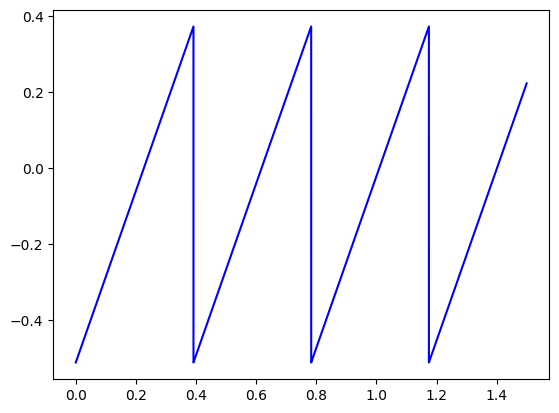

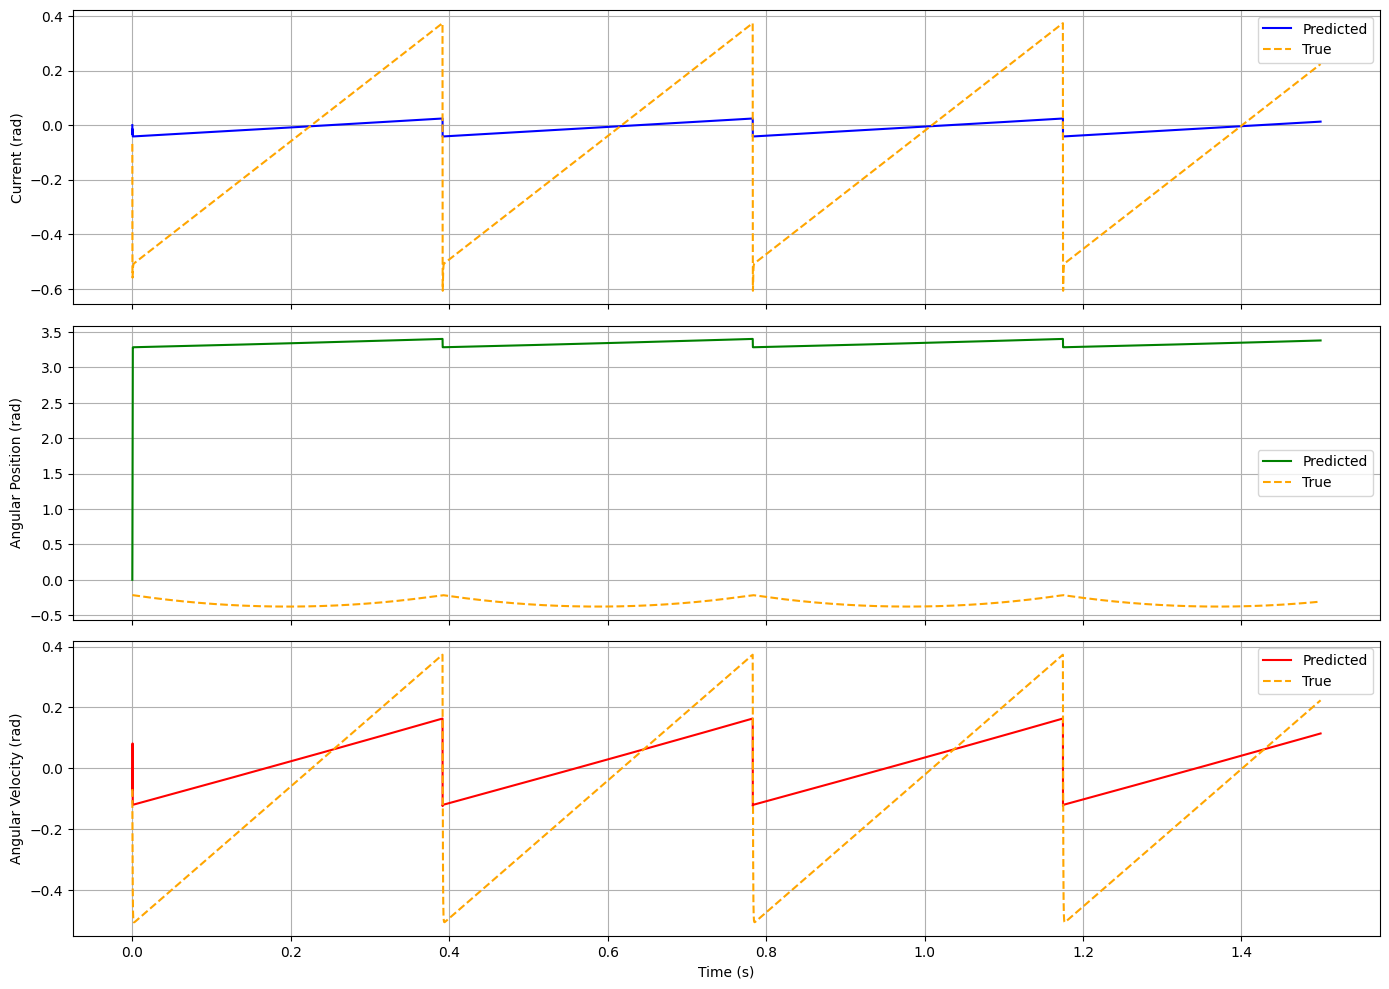

In [53]:
import matplotlib.pyplot as plt

# Prepare time axis
time = torch.arange(0, pred.shape[0]*5e-5, 5e-5)
#Plot u signals
plt.plot(time.cpu(), u_val[id, :], label='Current', color='blue')
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ['Current', 'Angular Position', 'Angular Velocity']
colors = ['blue', 'green', 'red']

for i in range(3):
    axs[i].plot(time.cpu(), pred[:, i].cpu().detach().numpy(), label='Predicted', color=colors[i])
    axs[i].plot(time.cpu(), x_val[id, :, i], label='True', color='orange', linestyle='--')
    axs[i].set_ylabel(f'{labels[i]} (rad)')
    axs[i].legend()
    axs[i].grid(True)

axs[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [54]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F
n_neurons = 32
dropout_rate = 0.1
class MotorModelResidual(nn.Module):
    def __init__(self, u_size=1, x_size=3):  
        super(MotorModelResidual, self).__init__()
        # Fully connected layers
        self.A1 = nn.Linear(x_size, n_neurons) 
        self.A2 = nn.Linear(n_neurons, n_neurons)
        self.A3 = nn.Linear(n_neurons, n_neurons)
        self.A4 = nn.Linear(n_neurons, n_neurons)
        self.outputA = nn.Linear(n_neurons, x_size)

        self.B1 = nn.Linear(u_size, n_neurons) 
        self.B2 = nn.Linear(n_neurons, n_neurons)
        self.outputB = nn.Linear(n_neurons, x_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        

    def forward(self, x0, u):
        
        outA = F.softplus(self.A1(x0))
        outA = self.dropout(F.softplus(self.A2(outA)))
        outA = self.dropout(F.softplus(self.A3(outA)))
        outA = self.dropout(F.softplus(self.A4(outA)))
        outA = self.outputA(outA)

        outB = F.softplus(self.B1(u))
        outB = self.dropout(F.softplus(self.B2(outB)))
        outB = self.outputB(outB)

        x = x0 + outA + outB  
        return x

# Create the model
model = MotorModelResidual()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

MotorModelResidual(
  (A1): Linear(in_features=3, out_features=32, bias=True)
  (A2): Linear(in_features=32, out_features=32, bias=True)
  (A3): Linear(in_features=32, out_features=32, bias=True)
  (A4): Linear(in_features=32, out_features=32, bias=True)
  (outputA): Linear(in_features=32, out_features=3, bias=True)
  (B1): Linear(in_features=1, out_features=32, bias=True)
  (B2): Linear(in_features=32, out_features=32, bias=True)
  (outputB): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 4614


In [ ]:
# Save final model
#torch.save(model.state_dict(), "resnet_time_stepper_ABmats_v1.pth")
#load model
model.load_state_dict(torch.load("resnet_time_stepper_ABmats_v1.pth"))

<All keys matched successfully>

In [56]:
# Choose a random test trajectory
from random import randint  

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
pred, mse, r2, raw_r2 = one_step_eval(model, torch.tensor(x_val[id,:], dtype=torch.float32).to(device),
                                torch.tensor(u_val[id,:], dtype=torch.float32).to(device).unsqueeze(-1))
print(f'Loss: {mse.item()}, R2: {r2.item()}')
print(f'Raw R2: {raw_r2}')
# Shapes
print(f'pred shape: {pred.shape}')  # (num_states,)
print(f'x_val shape: {x_val[id,:].shape}')  # (num_time_steps, num_states)

Loss: 258.2789306640625, R2: -5094.72216796875
Raw R2: tensor([-7757.5610, -2840.7915, -4685.8145], device='cuda:0')
pred shape: torch.Size([30000, 3])
x_val shape: (30000, 3)


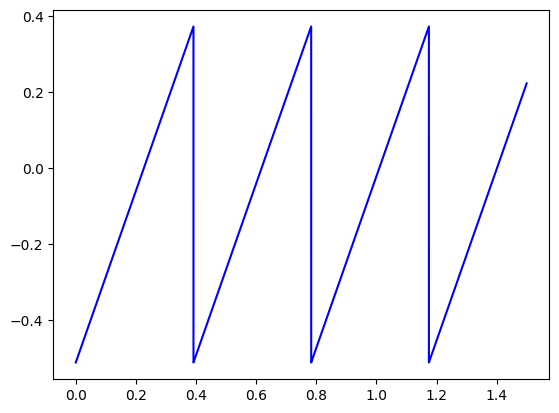

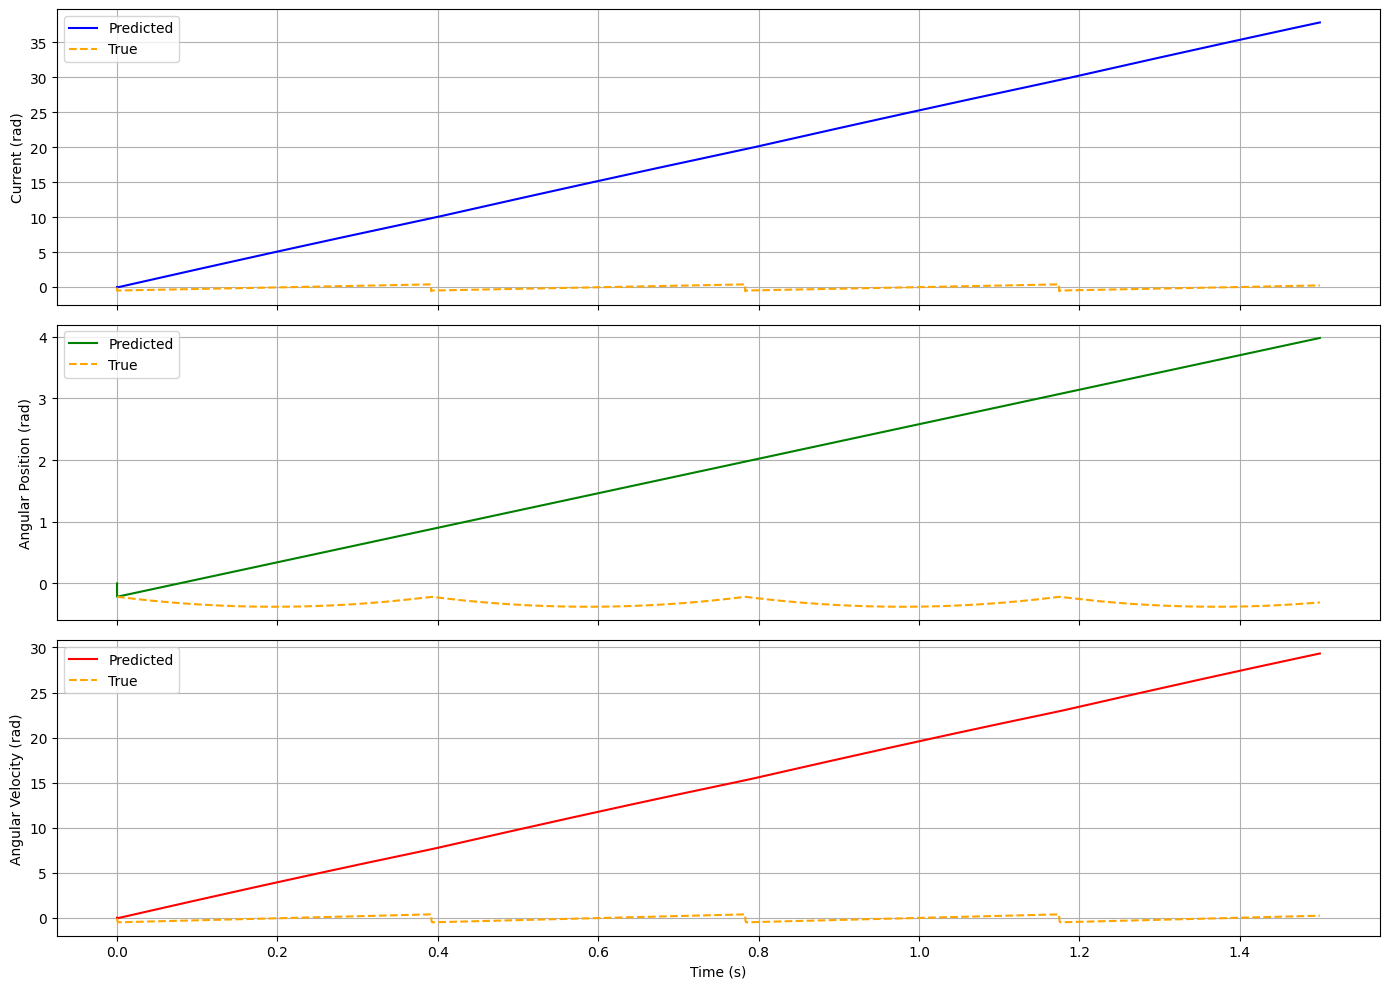

In [57]:
import matplotlib.pyplot as plt

# Prepare time axis
time = torch.arange(0, pred.shape[0]*5e-5, 5e-5)
#Plot u signals
plt.plot(time.cpu(), u_val[id, :], label='Current', color='blue')
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ['Current', 'Angular Position', 'Angular Velocity']
colors = ['blue', 'green', 'red']

for i in range(3):
    axs[i].plot(time.cpu(), pred[:, i].cpu().detach().numpy(), label='Predicted', color=colors[i])
    axs[i].plot(time.cpu(), x_val[id, :, i], label='True', color='orange', linestyle='--')
    axs[i].set_ylabel(f'{labels[i]} (rad)')
    axs[i].legend()
    axs[i].grid(True)

axs[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [58]:
# Runge-Kutta 4th order method for ODE solving
def rk4_step_func(func, x0, dt, u):
    k1 = func(x0, u)
    k1 = k1*dt

    k2 = func(x0+k1/2, u)
    k2 = k2*dt

    k3 = func(x0+k2/2, u)
    k3 = k3*dt

    k4 = func(x0+k3, u)
    k4 = k4*dt

    return x0 + (k1 + 2 * (k2 + k3) + k4) / 6

In [59]:
model = MotorModel()
dt = 1e-4
loaded_state_dict = torch.load("node_ABmats_v2.pth")
model.load_state_dict(loaded_state_dict)


<All keys matched successfully>

In [60]:
# One step evaluation
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score

def one_step_eval_rk4(model, x,u,dt):
    t = 0
    predictions = torch.zeros_like(x)
    model.eval()
    xk = x[0]
    torch.no_grad()
    for i in range(x.shape[0]-1):

        pred = rk4_step_func(model, xk, dt, u[i].unsqueeze(-1) )  # Integrate over a small time step
        predictions[i+1] = pred
        xk = pred
        # Backward and optimize
    r2 = r2_score(predictions[1:], x[1:])
    mse = mean_squared_error(predictions[1:], x[1:])
    raw_r2 = r2_score(predictions[1:], x[1:], multioutput='raw_values')
    return predictions, mse, r2, raw_r2

In [63]:
# Choose a random test trajectory
from random import randint  
test_size = 15000
model = MotorModel()
dt = 1e-4
loaded_state_dict = torch.load("node_ABmats_v2.pth")
model.load_state_dict(loaded_state_dict)


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

pred, mse, r2, raw_r2 = one_step_eval_rk4(model, torch.tensor(x_val[id,:test_size], dtype=torch.float32).to(device),
                                torch.tensor(u_val[id,:test_size], dtype=torch.float32).to(device).unsqueeze(-1),dt=dt)
print(f'Loss: {mse.item()}, R2: {r2.item()}')
print(f'Raw R2: {raw_r2}')
# Shapes
print(f'pred shape: {pred.shape}')  # (num_states,)
print(f'x_val shape: {x_val[id,:test_size].shape}')  # (num_time_steps, num_states)

Loss: 7.362148284912109, R2: -125.50450134277344
Raw R2: tensor([ -17.1872,  -13.1434, -346.1829], device='cuda:0')
pred shape: torch.Size([15000, 3])
x_val shape: (15000, 3)


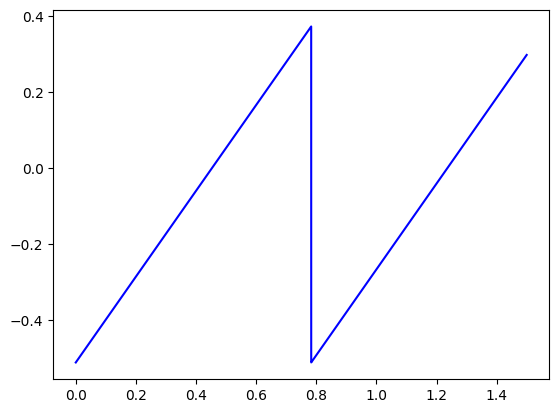

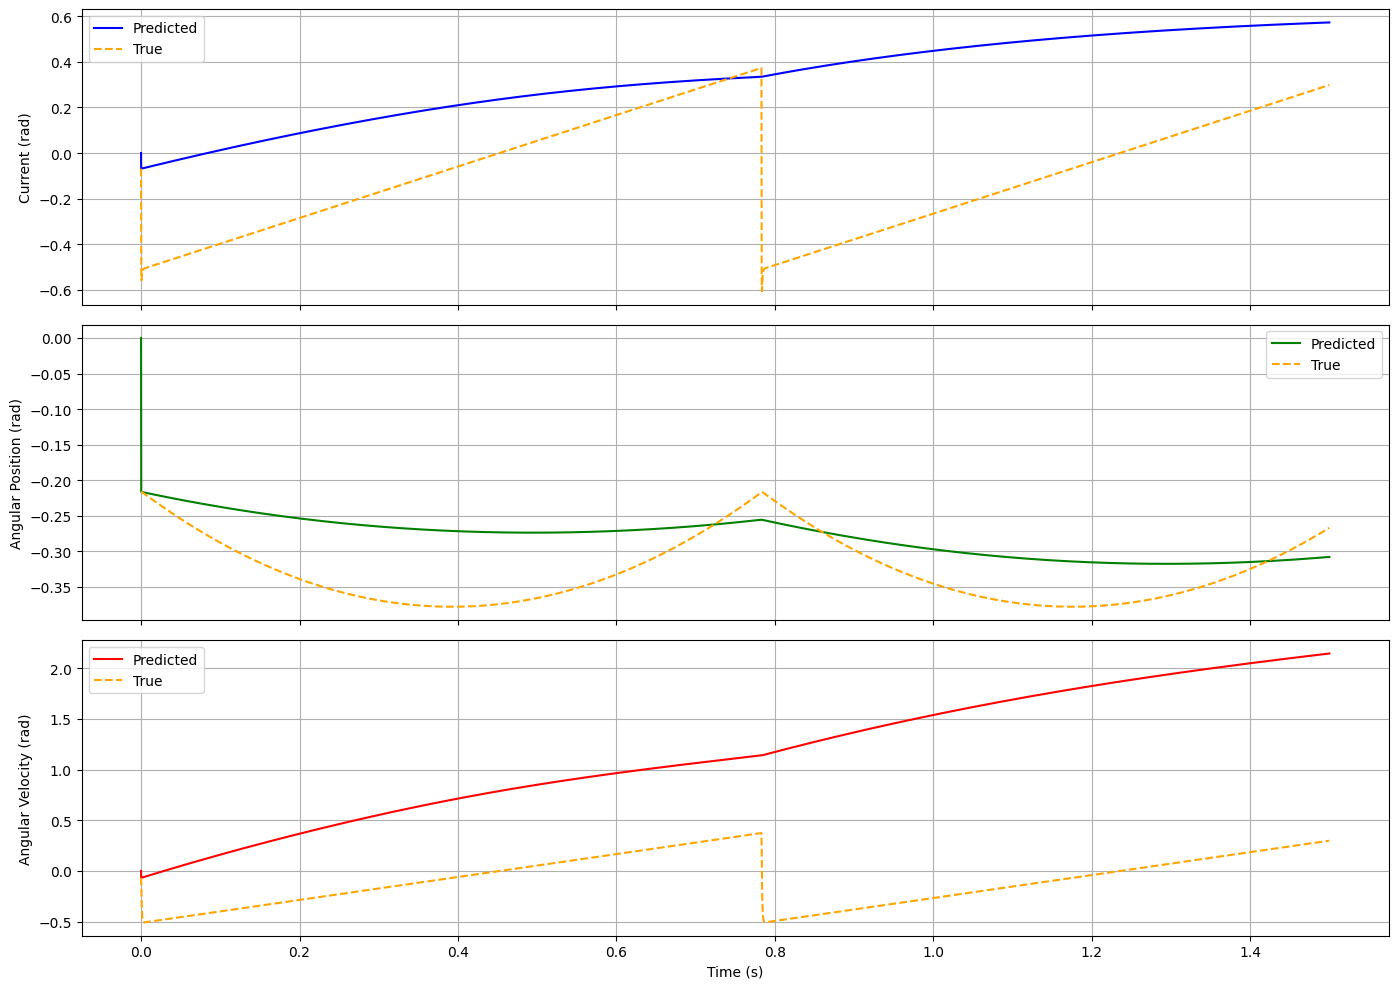

In [62]:

import matplotlib.pyplot as plt

# Prepare time axis
time = torch.arange(0, pred.shape[0]*dt, dt)[:test_size]
#Plot u signals
plt.plot(time.cpu(), u_val[id, :test_size], label='Current', color='blue')
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ['Current', 'Angular Position', 'Angular Velocity']
colors = ['blue', 'green', 'red']

for i in range(3):
    axs[i].plot(time.cpu()[:test_size], pred[:test_size, i].cpu().detach().numpy(), label='Predicted', color=colors[i])
    axs[i].plot(time.cpu()[:test_size], x_val[id, :test_size, i], label='True', color='orange', linestyle='--')
    axs[i].set_ylabel(f'{labels[i]} (rad)')
    axs[i].legend()
    axs[i].grid(True)

axs[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()